# Random Forest


<b> Objective: </b>
Conduct Experiments with Random Forest

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>

### Imports

In [5]:
!pip install xgboost

In [9]:
import sys
import os
COLAB_SESSION = True

DRIVE_PATH = ""
if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)

import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import  RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_absolute_error
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from GreenlandUtils import lonlatToUTM24N, Split, verifyStratification, displaySplit, MostCommonElements, Printable

Mounted at /content/drive


### Setup

In [31]:
DATA_TYPE = "Stream Sediment" #Stream Sediment | Whole Rock
MERGE_TYPE = "Mean Merge"
SOURCE_CSV = "stream-sediment" #stream-sediment | whole-rock

#Results are keyed by dataset and merge so a stream sediment run cannot overwrite a whole rock one
DATA_PATH = f"Data/{DATA_TYPE}/{MERGE_TYPE}/"
RESULTS_PATH = f"Results/{DATA_TYPE}/{MERGE_TYPE}/"
os.makedirs(f"{DRIVE_PATH}{RESULTS_PATH}", exist_ok=True)

def ReadColumnSchema(baseName: str) -> dict:
    with open(f"{DRIVE_PATH}Data/{baseName}.json", "r") as f:
        return json.load(f)

def ReadDataFrame(path: str, baseName: str) -> pd.DataFrame:
    return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")

def ReadSplit(path: str, baseName: str, df: pd.DataFrame) -> Split:
    with open(f"{DRIVE_PATH}{path}{baseName}.split", "r") as f:
        json_result = json.load(f)

    return Split({name: df.loc[idx] for name, idx in json_result.items()})

def ReadKFold(path: str, baseName: str, df: pd.DataFrame) -> list[Split]:
    with open(f"{DRIVE_PATH}{path}{baseName}.kfold", "r") as f:
        json_result = json.load(f)

    return [Split({name: df.loc[idx] for name, idx in json_result[key].items()}) for key in sorted(json_result, key=int)]


df = ReadDataFrame(DATA_PATH, "Data")
split = ReadSplit(DATA_PATH, "Holdout", df)
kfold_splits = ReadKFold(DATA_PATH, "5-Fold", df)

schema = ReadColumnSchema(SOURCE_CSV)
sampleCol = schema["sampleCol"]
metaCols = schema["metaCols"]
physicalCols = schema["physicalCols"]
locationCols = schema["locationCols"]

#Elements are whatever the schema does not claim, so a new dataset needs no code change
elementCols = [col for col in df.columns if col not in metaCols + physicalCols]
featureCols = physicalCols + elementCols


MIN_COVERAGE = 10
coverage = df[elementCols].notna().sum()
droppedCols = [col for col in elementCols if coverage[col] < MIN_COVERAGE]
elementCols = [col for col in elementCols if coverage[col] >= MIN_COVERAGE]

mostCommonElements = MostCommonElements(df, elementCols, top_n=10)
mostCommonElements = [element for element, _ in mostCommonElements]

#only train elements with more than 1000 samples
elementsToTrain = [col for col in elementCols if coverage[col] >= 1000]

print(f"Samples: {len(df)}   Elements: {len(elementCols)}   Folds: {len(kfold_splits)}")
print(f"Dropped ({len(droppedCols)}, under {MIN_COVERAGE} samples): {droppedCols}")
print(f"{len(elementsToTrain)} Targets: {elementsToTrain}")

/tmp/ipykernel_2568/3138283292.py:15: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")
Analyzing Elements: 100%|██████████| 87/87 [00:00<00:00, 5994.03it/s]

Samples: 17463   Elements: 87   Folds: 5
Dropped (6, under 10 samples): ['Pt ppb', 'Ir ppm', 'Sn %', 'B ppm', 'Re ppm', 'Si %']
71 Targets: ['SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3t wt%', 'Fe2O3 wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'Sum wt%', 'L.o.i. wt%', 'Ag ppm', 'Al %', 'As ppm', 'Ba ppm', 'Be ppm', 'Ca %', 'Cd ppm', 'Co ppm', 'Cr ppm', 'Cu ppm', 'Fe %', 'Hf ppm', 'K %', 'Mg %', 'Mn ppm', 'Mo ppm', 'Na %', 'Nb ppm', 'Ni ppm', 'P %', 'Pb ppm', 'Rb ppm', 'S %', 'Sb ppm', 'Sn ppm', 'Sr ppm', 'Ta ppm', 'Th ppm', 'Ti %', 'V ppm', 'W ppm', 'Zn ppm', 'Zr ppm', 'Sc ppm', 'Y ppm', 'La ppm', 'Ce ppm', 'Au ppb', 'Br ppm', 'Cs ppm', 'U ppm', 'Nd ppm', 'Sm ppm', 'Eu ppm', 'Tb ppm', 'Yb ppm', 'Lu ppm', 'Ga ppm', 'Ge ppm', 'Tl ppm', 'Pr ppm', 'Gd ppm', 'Dy ppm', 'Ho ppm', 'Er ppm', 'Tm ppm', 'Mn %', 'Cl %']


In [32]:
def ValidateKFold(kfold_splits: list[Split], df: pd.DataFrame):
    test_sets = [set(s.data["test"].index) for s in kfold_splits]

    print("test sizes:", [len(t) for t in test_sets])
    print("union:", len(set().union(*test_sets)), "of", len(df))
    print("pairwise overlaps:", [len(a & b) for i, a in enumerate(test_sets)
                                            for b in test_sets[i+1:]])

    for i, s in enumerate(kfold_splits):
        tr, te = set(s.data["train"].index), set(s.data["test"].index)
        print(f"fold {i}: train {len(tr)}, test {len(te)}, leak {len(tr & te)}")


ValidateKFold(kfold_splits, df)

test sizes: [3493, 3493, 3493, 3492, 3492]
union: 17463 of 17463
pairwise overlaps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
fold 0: train 13970, test 3493, leak 0
fold 1: train 13970, test 3493, leak 0
fold 2: train 13970, test 3493, leak 0
fold 3: train 13971, test 3492, leak 0
fold 4: train 13971, test 3492, leak 0


### Naive Regressor

In [33]:
def ArrangeData(df: pd.DataFrame, element: str, elementCols: list[str]):
    df = df.copy()
    df = df.dropna(subset=[element])
    X = df[elementCols].copy()
    y = df[element].copy()
    X = X.drop(columns=[element], errors='ignore')

    return X, y

def DropDegenerateColumns(X_train: pd.DataFrame, X_test: pd.DataFrame):
    #A KNN column can end up constant or near-empty on a given fold even when its
    #source element is fine, which is the one input HistGradientBoosting cannot bin
    usable = [col for col in X_train.columns if X_train[col].nunique(dropna=True) >= 2]

    return X_train[usable], X_test[usable]

def MakeModel(modelType: str="hgb", n_jobs: int=-1, estimators: int=200):
    #HistGradientBoosting threads internally and takes no n_jobs
    if modelType == "rf":
        return RandomForestRegressor(n_estimators=estimators, random_state=42, n_jobs=n_jobs)
    return HistGradientBoostingRegressor(max_iter=estimators, random_state=42)

def TrainRandomForest(df_train: pd.DataFrame, df_test: pd.DataFrame, element: str, elementCols: list[str], n_jobs:int=-1, estimators:int=200, modelType:str="hgb"):
    X_train, y_train = ArrangeData(df_train, element, elementCols)
    X_test, y_test = ArrangeData(df_test, element, elementCols)

    if X_train.empty or X_test.empty:
        return { "r2": None, "mae": None }

    X_train, X_test = DropDegenerateColumns(X_train, X_test)
    if X_train.empty:
        return { "r2": None, "mae": None }

    model = MakeModel(modelType, n_jobs=n_jobs, estimators=estimators)
    model.fit(X_train, y_train)

    r2 = model.score(X_test, y_test)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return { "r2": r2, "mae": mae, "y_pred": y_pred, "y_test": y_test }



train, test = split.data["train"], split.data["test"]

for modelType in ("rf", "hgb"):
    score = TrainRandomForest(train, test, element="CaO wt%", elementCols=featureCols, estimators=40, modelType=modelType)
    print(f"{modelType:>4}   R2: {score['r2']:.4f}   MAE: {score['mae']:.4f}")

  rf   R2: 0.9658   MAE: 0.0400
 hgb   R2: 0.9604   MAE: 0.0453


In [44]:
from joblib import Parallel, delayed


def TrainAllElements(split: Split, elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, modelType: str="hgb", **kwargs):

    train, test = split.data["train"], split.data["test"]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(train, test, element, elementCols, n_jobs=1, modelType=modelType)
        for element in elementsToTrain
    )

    return dict(zip(elementsToTrain, scores))

def TrainAllElementsKFold(kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, modelType: str="hgb", **kwargs):

    jobs = [
        (element, foldIdx, split)
        for element in elementsToTrain
        for foldIdx, split in enumerate(kfold_splits)
    ]

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainRandomForest)(
            split.data["train"], split.data["test"], element, elementCols, n_jobs=1, modelType=modelType
        )
        for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results

MODEL_TYPE = "rf"

results = TrainAllElements(split, elementsToTrain, elementCols, n_jobs=-1, modelType=MODEL_TYPE)
results_kfold = TrainAllElementsKFold(kfold_splits, elementsToTrain, elementCols, n_jobs=-1, modelType=MODEL_TYPE)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 11.3min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed: 15.4min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed: 19.3min
[Parallel(n_jobs=-1)]: Done  64 out of  71 | elapsed: 19.7min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done  71 out of  71 | elapsed: 20.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  8.1min
[Parallel(n_jo

In [46]:
def SaveResults(results: dict, path: str, baseName: str):
    for _, score in results.items():
        if "y_pred" in score:
            score["y_pred"] = score["y_pred"].tolist() if not isinstance(score["y_pred"], list) else score["y_pred"]
        if "y_test" in score:
            score["y_test"] = score["y_test"].tolist() if not isinstance(score["y_test"], list) else score["y_test"]

    with open(f"{DRIVE_PATH}{path}{baseName}.json", "w") as f:
        json.dump(results, f, indent=4)
        
def LoadResults(path: str, baseName: str) -> dict:
    results = None
    try:
        with open(f"{DRIVE_PATH}{path}{baseName}.json", "r") as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {DRIVE_PATH}{path}{baseName}.json")
    return results

def AggregateFolds(kfoldResults: dict):
    aggregated = {}

    for element, folds in kfoldResults.items():
        valid = [s for s in folds.values() if s["r2"] is not None and not np.isnan(s["r2"])]
        if not valid:
            aggregated[element] = { "r2": None, "mae": None }
            continue

        aggregated[element] = {
            "r2": float(np.mean([s["r2"] for s in valid])),
            "r2_std": float(np.std([s["r2"] for s in valid])),
            "mae": float(np.mean([s["mae"] for s in valid])),
            "y_pred": np.concatenate([s["y_pred"] for s in valid]),
            "y_test": np.concatenate([s["y_test"] for s in valid]),
        }

    return aggregated

#Model name goes in the filename so RF and HGB runs do not overwrite each other
MODEL_NAMES = { "rf": "RandomForest", "hgb": "HistGradientBoosting", "xgb": "XGBoost" }

SaveResults(results, RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}")
SaveResults(AggregateFolds(results_kfold), RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold_Cov1000")

In [47]:
def PooledR2Log(results: dict):
    ss_res, ss_tot = 0.0, 0.0

    for score in results.values():
        if score["r2"] is None or "y_test" not in score:
            continue

        y_test = np.asarray(score["y_test"], dtype=float)
        y_pred = np.asarray(score["y_pred"], dtype=float)

        #Log10 scale so wt%/ppm/ppb elements contribute comparably (drop BDL zeros)
        valid = (y_test > 0) & (y_pred > 0)
        if valid.sum() < 2:
            continue

        y_test_log = y_test[valid]
        y_pred_log = y_pred[valid]

        ss_res += ((y_test_log - y_pred_log) ** 2).sum()
        ss_tot += ((y_test_log - y_test_log.mean()) ** 2).sum()

    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def GlobalScores(printable: Printable, results: dict):
    valid_r2 = [s["r2"] for s in results.values() if s["r2"] is not None and not np.isnan(s["r2"])]

    printable.add("Mean R2 Score", f"{np.mean(valid_r2):.4f}")
    printable.add("Median R2 Score", f"{np.median(valid_r2):.4f}")
    printable.add("Pooled R2 Score (log10)", f"{PooledR2Log(results):.4f}")

def ReportResults(results: dict, title: str = "Element Scores"):
    printable = Printable()
    printable.title(title)
    for element, score in results.items():
        if score["r2"] is None:
            continue

        r2 = f"R2: {score['r2']:>8.4f}"
        #r2_std only exists for k-fold results, so pad single-split rows to match
        if "r2_std" in score:
            r2 += f" ± {score['r2_std']:.4f}"
        else:
            r2 += " " * 9

        printable.add(element, f"{r2}   MAE: {score['mae']:.4f}")

    printable.rest()
    printable.title("Global Score")

    GlobalScores(printable, results)

    printable.pretty()

ReportResults(results, "Holdout")

ReportResults(AggregateFolds(results_kfold), "5-Fold")

========================== Holdout ==========================
SiO2 wt%:                  R2:   0.9869            MAE: 0.0089
TiO2 wt%:                  R2:   0.9295            MAE: 0.0433
Al2O3 wt%:                 R2:   0.9754            MAE: 0.0193
Fe2O3t wt%:                R2:   0.9571            MAE: 0.0297
Fe2O3 wt%:                 R2:   0.9623            MAE: 0.0286
MnO wt%:                   R2:   0.9022            MAE: 0.0453
MgO wt%:                   R2:   0.9278            MAE: 0.0490
CaO wt%:                   R2:   0.9666            MAE: 0.0395
Na2O wt%:                  R2:   0.9688            MAE: 0.0355
K2O wt%:                   R2:   0.9272            MAE: 0.0381
P2O5 wt%:                  R2:   0.8807            MAE: 0.0682
Sum wt%:                   R2:   0.9832            MAE: 0.0022
L.o.i. wt%:                R2:   0.8976            MAE: 0.0893
Ag ppm:                    R2:   0.8835            MAE: 0.1339
Al %:                      R2:   0.9598            MAE: 

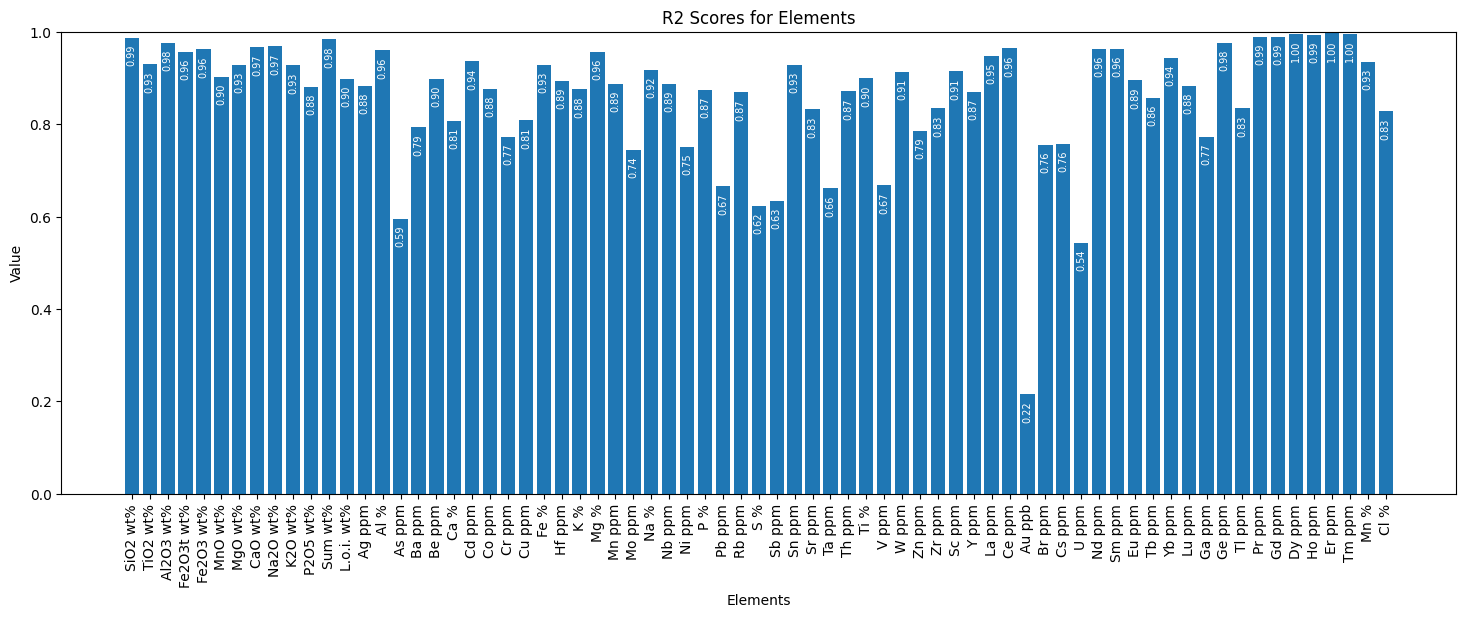

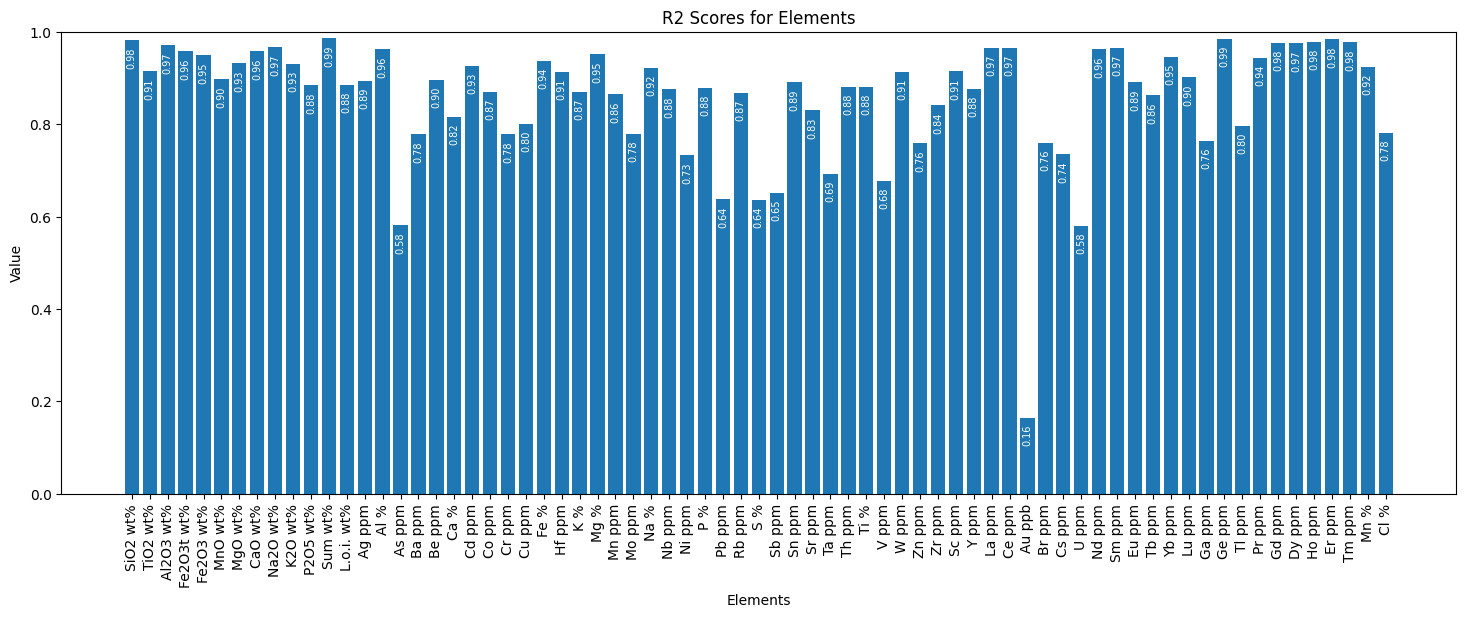

In [48]:
def DisplayElementScores(elementScores: dict):
    scores_df = pd.DataFrame.from_dict(elementScores, orient='index')
    scores_df = scores_df[['r2', 'mae']]
    display(scores_df)

def DisplayElementScoresGraph(elementScores:dict, metric="r2", title="Element Scores"):

    scores = []
    for element, score in elementScores.items():
        if score[metric] is not None:
            scores.append((element, score[metric]))

    labels, values = zip(*scores)


    plt.figure(figsize=(18, 6))
    bars = plt.bar(labels, values)
    plt.bar_label(bars, fmt="%.2f", padding=-20, rotation=90, fontsize=7, color="white")
    plt.ylim(0, 1)
    plt.xlabel("Elements")
    plt.ylabel("Value")
    plt.xticks(rotation=90)
    plt.title(title)

    plt.show()

DisplayElementScoresGraph(results, metric="r2", title="R2 Scores for Elements")
DisplayElementScoresGraph(AggregateFolds(results_kfold), metric="r2", title="R2 Scores for Elements")

### Regressor + K Nearest Neighbours

##### Building the Neighbour Mapping

In [49]:
def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def BuildNeighbourMapping(df: pd.DataFrame, split: Split, k: int = 20, excludeSameLocation: bool = False) -> tuple[np.ndarray, np.ndarray]:

    #Build context around only train split
    allCoords = ProjectedCoords(df)
    trainPos = df.index.get_indexer(split.data["train"].index)
    trainCoords = allCoords[trainPos]

    #Fetch a good amount of neighbours if we are excluding co-located samples since we need filter out later (aka max equal coords padding)
    #If including co-located samples, just filter out self (aka 1 padding)
    padding = int(df.groupby(["Longitude", "Latitude"]).size().max()) if excludeSameLocation else 1
    nNeighbours = min(k + padding, len(trainPos))

    tree = NearestNeighbors(n_neighbors=nNeighbours).fit(trainCoords)
    distances, positions = tree.kneighbors(allCoords)
    neighbourPos = trainPos[positions]

    #Exlude self and distance 0 neighbours
    rejected = neighbourPos == np.arange(len(df))[:, None]
    if excludeSameLocation:
        rejected |= distances == 0

    distances = np.where(rejected, np.inf, distances)
    ordered = np.argsort(distances, axis=1)[:, :k]

    return np.take_along_axis(neighbourPos, ordered, axis=1), np.take_along_axis(distances, ordered, axis=1)


def BuildNeighbourValues(df: pd.DataFrame, elementCols: list[str], neighbourPos: np.ndarray, neighbourDist: np.ndarray, k: int = 5) -> np.ndarray:

    elements = df[elementCols].to_numpy(dtype=float)

    values = elements[neighbourPos[:, :k]]
    values[~np.isfinite(neighbourDist[:, :k])] = np.nan

    return values


def NeighbourMeans(neighbourValues: np.ndarray) -> np.ndarray:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmean(neighbourValues, axis=1)


neighbourPos, neighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=5)
neighbourValues = BuildNeighbourValues(df, elementCols, neighbourPos, neighbourDist, k=5)

printable = Printable()
printable.title("Neighbour Mapping Info")
printable.add("Mapping Shape", neighbourPos.shape)
printable.add("Values Shape", neighbourValues.shape) #samples x neighbours x elements
printable.rest()
printable.add("Distances Median", f"{np.median(neighbourDist)/1000:.3f}")
printable.add("Distances Mean", f"{np.mean(neighbourDist)/1000:.3f}")
printable.add("Distances at 0m", f"{len(neighbourDist == 0)}")
printable.flush()

========= Neighbour Mapping Info =========
Mapping Shape:      (17463, 5)
Values Shape:       (17463, 5, 87)


Distances Median:   3.231
Distances Mean:     3.940
Distances at 0m:    17463


##### KNN Variants

In [ ]:
#Mean target element
def CreateKNNFrame_A(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    target = elementCols.index(element)
    means = NeighbourMeans(neighbourValues)[:, target]
    return pd.DataFrame({f"{k}-KNN_{element}_mean": means}, index=df.index)

#Individual target element values
def CreateKNNFrame_B(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    target = elementCols.index(element)
    columns = {f"{i+1}of{k}-KNN_{element}": neighbourValues[:, i, target] for i in range(k)}
    return pd.DataFrame(columns, index=df.index)

#All element means
def CreateKNNFrame_C(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    means = NeighbourMeans(neighbourValues)
    columns = {f"{k}-KNN_{e}_mean": means[:, j] for j, e in enumerate(elementCols)}
    return pd.DataFrame(columns, index=df.index)

#All element individual values
def CreateKNNFrame_D(df: pd.DataFrame, elementCols: list[str], element: str, neighbourValues: np.ndarray, k: int) -> pd.DataFrame:
    columns = {f"{i+1}of{k}-KNN_{e}": neighbourValues[:, i, j]
               for j, e in enumerate(elementCols) for i in range(k)}
    return pd.DataFrame(columns, index=df.index)


#KNN_VARIANTS = { "A": CreateKNNFrame_A, "B": CreateKNNFrame_B, "C": CreateKNNFrame_C, "D": CreateKNNFrame_D }
KNN_VARIANTS = { "A": CreateKNNFrame_A, "B": CreateKNNFrame_B, "C": CreateKNNFrame_C, "D": CreateKNNFrame_D }

for name, builder in KNN_VARIANTS.items():
    frame = builder(df, elementCols, "CaO wt%", neighbourValues, 5)
    printable.add(f"Variant {name}", f"{frame.shape[1]:>3} added columns")

printable.flush()

Variant A:     1 added columns
Variant B:     5 added columns
Variant C:    87 added columns
Variant D:   435 added columns


##### Training

In [ ]:
#Storage dtype for the KNN frames. Set back to np.float64 for full precision
KNN_FRAME_DTYPE = np.float16


def TrainAllElementsKFoldKNN(df: pd.DataFrame, kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, n_jobs: int=-1, k: int=5, maskFunction: callable =CreateKNNFrame_A, excludeSameLocation: bool=False, modelType: str="hgb", **kwargs):

    jobs = [] # element x (foldIdx, split)
    dfs = {} # (element, foldIdx) -> DataFrame

    #Build neighbour mapping per fold 
    for foldIdx, split in enumerate(kfold_splits):
        neighbourPos, neighbourDist = BuildNeighbourMapping(df, split, k=k, excludeSameLocation=excludeSameLocation)
        neighbourValues = BuildNeighbourValues(df, elementCols, neighbourPos, neighbourDist, k=k)

        for element in elementsToTrain:
            dfs[(element, foldIdx)] = maskFunction(df, elementCols, element, neighbourValues, k).astype(KNN_FRAME_DTYPE)
            jobs.append((element, foldIdx, split))
    

    def TrainJob(element, foldIdx, split):
        frame = dfs[(element, foldIdx)]
        full = pd.concat([df[elementCols], frame], axis=1)
        return TrainRandomForest(
            full.loc[split.data["train"].index],
            full.loc[split.data["test"].index],
            element,
            elementCols + frame.columns.tolist(),
            n_jobs=1,
            estimators=200,
            modelType=modelType
        )

    scores = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(TrainJob)(element, foldIdx, split) for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results


results_kfold_knn = {}
MODEL_TYPE = "rf"

#Aggregate before storing, so results_kfold_knn holds aggregated results on both the
#cached and the freshly trained path (the cache on disk is aggregated either way)
for name, maskFunction in KNN_VARIANTS.items():
    results_kfold_knn[name] = LoadResults(RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_{name}_ExcludingColocation_Cov1000")
    if results_kfold_knn[name] is None:
        raw = TrainAllElementsKFoldKNN(df, kfold_splits, elementsToTrain, elementCols, n_jobs=-1, k=20, maskFunction=maskFunction, excludeSameLocation=True, modelType=MODEL_TYPE)
        results_kfold_knn[name] = AggregateFolds(raw)
        SaveResults(results_kfold_knn[name], RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_{name}_ExcludingColocation_Cov1000")

In [41]:
for name in KNN_VARIANTS:
    ReportResults(results_kfold_knn[name], f"5-Fold + KNN {name}")

======================= 5-Fold + KNN A =======================
SiO2 wt%:                  R2:   0.9850 ± 0.0046   MAE: 0.0069
TiO2 wt%:                  R2:   0.9336 ± 0.0074   MAE: 0.0423
Al2O3 wt%:                 R2:   0.9747 ± 0.0063   MAE: 0.0174
Fe2O3t wt%:                R2:   0.9620 ± 0.0171   MAE: 0.0271
Fe2O3 wt%:                 R2:   0.9583 ± 0.0104   MAE: 0.0262
MnO wt%:                   R2:   0.9127 ± 0.0090   MAE: 0.0448
MgO wt%:                   R2:   0.9453 ± 0.0059   MAE: 0.0417
CaO wt%:                   R2:   0.9663 ± 0.0023   MAE: 0.0375
Na2O wt%:                  R2:   0.9714 ± 0.0055   MAE: 0.0335
K2O wt%:                   R2:   0.9443 ± 0.0041   MAE: 0.0340
P2O5 wt%:                  R2:   0.9006 ± 0.0081   MAE: 0.0633
Sum wt%:                   R2:   0.9778 ± 0.0042   MAE: 0.0023
L.o.i. wt%:                R2:   0.9211 ± 0.0063   MAE: 0.0757
Ag ppm:                    R2:   0.9028 ± 0.0228   MAE: 0.1217
Al %:                      R2:   0.9664 ± 0.0010   MAE:

### Results Comparison

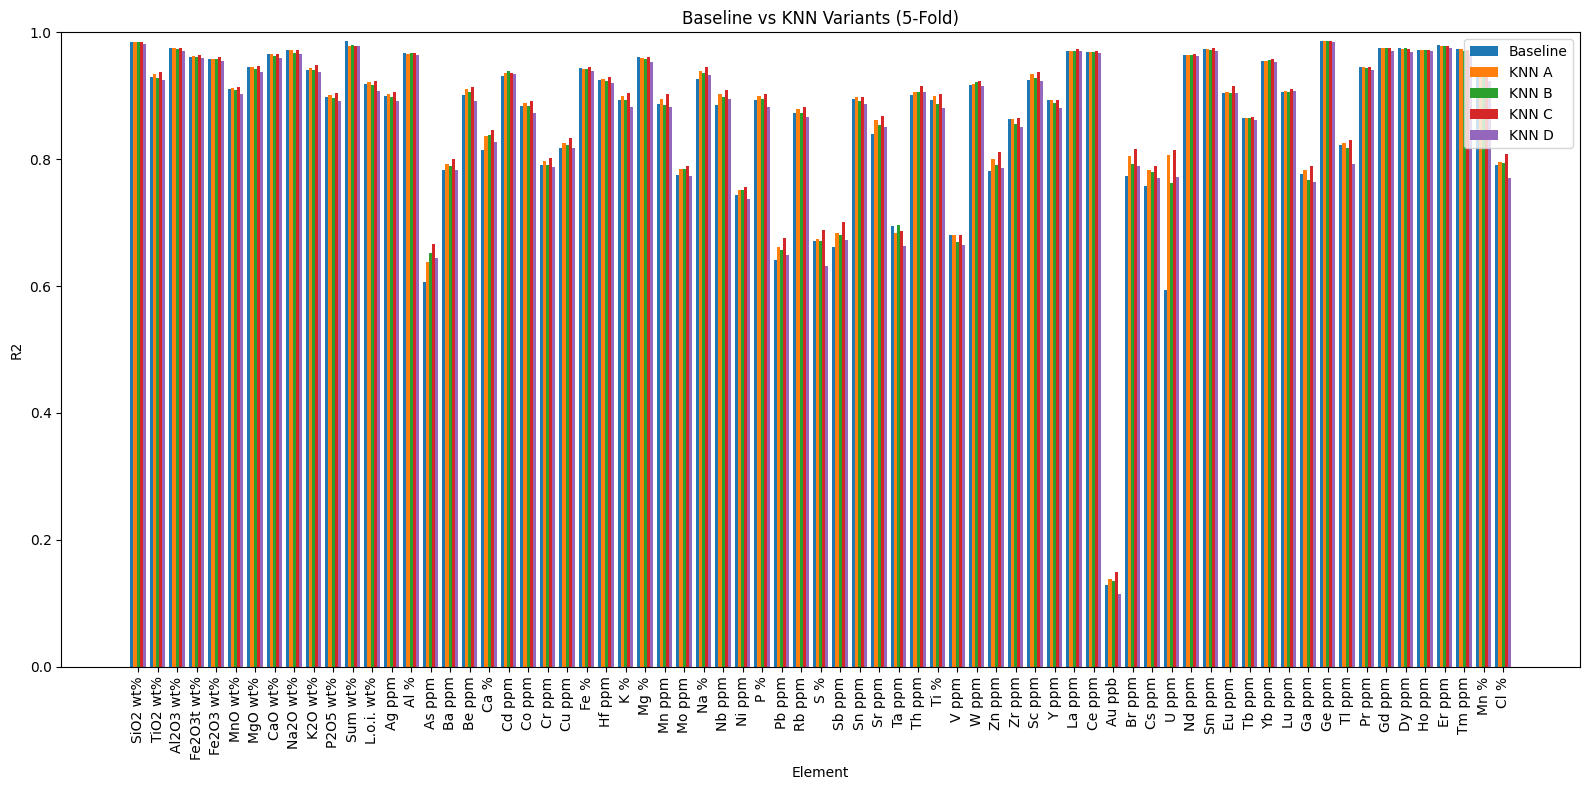

In [42]:
def CompareVariantsOnGraph(allResults: dict[str, dict], elements: list[str], metric="r2", title="Comparison of KNN Variants"):
    names = list(allResults.keys())
    x = np.arange(len(elements))
    width = 0.8 / len(names)

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, name in enumerate(names):
        values = [allResults[name][element][metric] or 0 for element in elements]
        offset = (i - (len(names) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=name)

    ax.set_xlabel("Element")
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=90)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()


#results_kfold_knn is already aggregated; results_kfold is still raw per-fold
allResults = { "Baseline": AggregateFolds(results_kfold) }
allResults.update({ f"KNN {name}": results_kfold_knn[name] for name in KNN_VARIANTS })

CompareVariantsOnGraph(allResults, elementsToTrain, metric="r2", title="Baseline vs KNN Variants (5-Fold)")

In [43]:
#Added column counts, so the scores can be read against feature count
sampleNeighbourPos, sampleNeighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=5)
sampleNeighbourValues = BuildNeighbourValues(df, elementCols, sampleNeighbourPos, sampleNeighbourDist, k=5)

addedColumns = { "Baseline": 0 }
addedColumns.update({ f"KNN {name}": KNN_VARIANTS[name](df, elementCols, mostCommonElements[0], sampleNeighbourValues, 5).shape[1]
                      for name in KNN_VARIANTS })

printable = Printable()
printable.title("Mean R2 by Variant")
for name, res in allResults.items():
    valid = [s["r2"] for s in res.values() if s["r2"] is not None]
    stds = [s["r2_std"] for s in res.values() if s.get("r2_std") is not None]
    printable.add(name, f"R2: {np.mean(valid):.4f} ± {np.mean(stds):.4f}   (+{addedColumns[name]} cols)")
printable.pretty()

============= Mean R2 by Variant =============
Baseline:    R2: 0.8676 ± 0.0137   (+0 cols)
KNN A:       R2: 0.8757 ± 0.0130   (+1 cols)
KNN B:       R2: 0.8724 ± 0.0131   (+5 cols)
KNN C:       R2: 0.8801 ± 0.0132   (+87 cols)
KNN D:       R2: 0.8659 ± 0.0139   (+435 cols)


### K-Sweep

In [23]:
#     results_kfold_knn[name] = TrainAllElementsKFoldKNN(df, kfold_splits, mostCommonElements, elementCols, n_jobs=-1, k=5, maskFunction=maskFunction, excludeSameLocation=True, modelType=MODEL_TYPE)
#     SaveResults(AggregateFolds(results_kfold_knn[name]), RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_{name}_ExcludingColocation")


SWEEPS = [1, 3, 5, 10, 20, 50, 100]

results_knn_sweep = {}
for k in SWEEPS:
    results_knn_sweep[k] = {}
    for name, maskFunction in KNN_VARIANTS.items():
        results_knn_sweep[k][name] = LoadResults(RESULTS_PATH, f"K-Sweep_{k}_{name}")
        if results_knn_sweep[k][name] is None:
            print(f"Training KNN with k={k} and mask function {name}")
            
            raw = TrainAllElementsKFoldKNN(df, kfold_splits, mostCommonElements, elementCols, n_jobs=4, k=k, maskFunction=maskFunction, excludeSameLocation=True, modelType="hgb")
            results_knn_sweep[k][name] = AggregateFolds(raw)
            SaveResults(results_knn_sweep[k][name], RESULTS_PATH, f"K-Sweep_{k}_{name}")

File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/K-Sweep_50_D.json
Training KNN with k=50 and mask function D


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  3.8min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.8min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  9.5min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 11.5min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 17.1min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 20.9min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed: 24.1min finished


File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/K-Sweep_100_A.json
Training KNN with k=100 and mask function A


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    4.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    6.9s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   12.1s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   15.3s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   21.9s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   27.7s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:   32.0s finished


File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/K-Sweep_100_B.json
Training KNN with k=100 and mask function B


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   11.9s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   19.4s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   32.1s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   40.9s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   58.4s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:  1.4min finished


File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/K-Sweep_100_C.json
Training KNN with k=100 and mask function C


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   10.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   14.7s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   24.5s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   30.0s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   43.6s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   54.0s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:  1.0min finished


File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/K-Sweep_100_D.json
Training KNN with k=100 and mask function D


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  8.6min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 12.8min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 21.1min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 25.6min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 37.9min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 46.4min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed: 53.5min finished


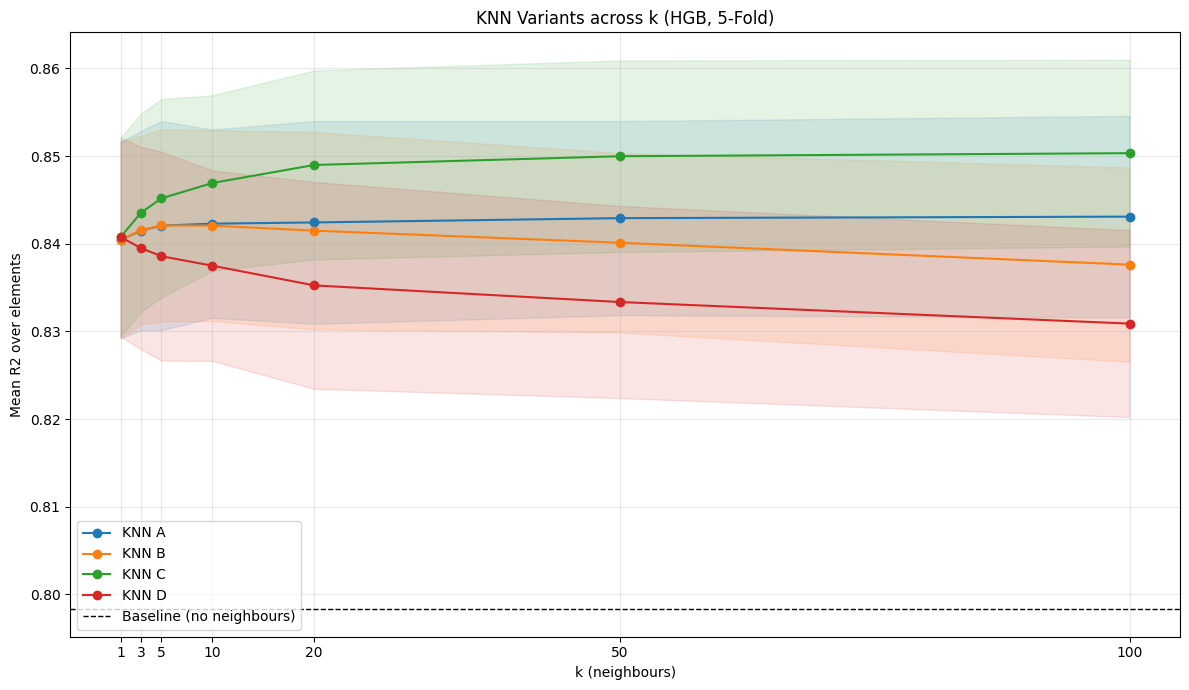

In [24]:
def DisplayKSweepGraph(sweepResults: dict[int, dict[str, dict]], baseline: dict=None, metric="r2", title="KNN Variants across k"):

    ks = sorted(sweepResults)
    variants = list(sweepResults[ks[0]].keys())

    fig, ax = plt.subplots(figsize=(12, 7))

    for name in variants:
        means, stds = [], []
        for k in ks:
            #Already aggregated by the sweep cell, on both the cached and the trained path
            aggregated = sweepResults[k][name]
            scores = [s[metric] for s in aggregated.values() if s[metric] is not None]
            #Fold spread averaged over elements, so the band shows run-to-run noise
            spread = [s["r2_std"] for s in aggregated.values() if s.get("r2_std") is not None]
            means.append(np.mean(scores))
            stds.append(np.mean(spread) if spread else 0.0)

        means, stds = np.array(means), np.array(stds)

        line, = ax.plot(ks, means, marker="o", label=f"KNN {name}")
        ax.fill_between(ks, means - stds, means + stds, alpha=0.12, color=line.get_color())

    #Without the no-neighbour baseline the vertical scale means very little
    if baseline is not None:
        aggregated = AggregateFolds(baseline)
        scores = [s[metric] for s in aggregated.values() if s[metric] is not None]
        ax.axhline(np.mean(scores), color="black", linestyle="--", linewidth=1, label="Baseline (no neighbours)")

    ax.set_xlabel("k (neighbours)")
    ax.set_ylabel(f"Mean {metric.upper()} over elements")
    ax.set_title(title)
    ax.set_xticks(ks)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


#results_knn_sweep is aggregated per (k, variant); results_kfold is still raw per-fold
DisplayKSweepGraph(results_knn_sweep, baseline=results_kfold, title="KNN Variants across k (HGB, 5-Fold)")

### Feature Set Combinations

Every run so far has fed the model a sample's own chemistry. This ablation changes only what
goes into `X`, keeping the same 10 elements, the same 5 folds and the same model, so each
source can be scored alone and in combination.

The question the table answers is which source the signal actually comes from:

| feature set | question |
|---|---|
| `Chemistry` | the reference - a sample's other measured elements |
| `Physics` | what do the three geophysical grids carry on their own? |
| `Location` | what is plain position worth? |
| `Neighbours` | what is the neighbourhood worth without own chemistry? |
| `Chemistry + Physics` | do the grids add anything on top of chemistry? |
| `Chemistry + Location` | does position add anything on top of chemistry? |
| `Physics + Location` | **the key row** - is geophysics real physics, or a position proxy? |

`Physics` against `Location` is the one that matters. Depth to Moho correlates 0.75 with
northing, and only 42% of elements correlate with a geophysical grid more strongly than with
a bare coordinate. If physics scores no better than raw x/y then these grids encode *where a
sample is* rather than *what lies underfoot*, which changes how RQ2 gets framed.

Neighbour columns are fold-dependent, so `Neighbours` is built per fold the same way the KNN
variants are. Everything else is static per sample.

In [25]:
#Neighbour columns depend on the fold, so they are named here and built inside the trainer
NEIGHBOUR_KEY = "Neighbours"

featureSetCombinations = {
    "Chemistry":            elementCols,
    "Physics":              physicalCols,
    "Location":             locationCols,
    NEIGHBOUR_KEY:          [],
    "Chemistry + Physics":  elementCols + physicalCols,
    "Chemistry + Location": elementCols + locationCols,
    "Physics + Location":   physicalCols + locationCols,
}

printable = Printable()
printable.title("Feature Sets")
for name, cols in featureSetCombinations.items():
    printable.add(name, f"{len(cols) if cols else len(elementCols):>3} columns" + ("   (built per fold)" if name == NEIGHBOUR_KEY else ""))
printable.flush()

==================== Feature Sets ====================
Chemistry:               68 columns
Physics:                  3 columns
Location:                 2 columns
Neighbours:              68 columns   (built per fold)
Chemistry + Physics:     71 columns
Chemistry + Location:    70 columns
Physics + Location:       5 columns


In [26]:
def TrainAllElementsKFoldFeatureSet(df: pd.DataFrame, kfold_splits: list[Split], elementsToTrain: list[str], featureCols: list[str]=None, n_jobs: int=-1, k: int=20, useNeighbours: bool=False, excludeSameLocation: bool=True, modelType: str="hgb", **kwargs):

    jobs = []   # (element, foldIdx, split)
    dfs = {}    # (element, foldIdx) -> DataFrame of the columns for that fit

    for foldIdx, split in enumerate(kfold_splits):

        #Only the neighbour set needs the mapping, and it is fold-dependent so it lives here.
        #Variant C (all element means) is used: the k-sweep showed pooling beats enumerating.
        if useNeighbours:
            neighbourPos, neighbourDist = BuildNeighbourMapping(df, split, k=k, excludeSameLocation=excludeSameLocation)
            neighbourValues = BuildNeighbourValues(df, elementCols, neighbourPos, neighbourDist, k=k)

        for element in elementsToTrain:
            if useNeighbours:
                dfs[(element, foldIdx)] = CreateKNNFrame_C(df, elementCols, element, neighbourValues, k)
            else:
                dfs[(element, foldIdx)] = df[featureCols]

            jobs.append((element, foldIdx, split))


    #The frame is passed in rather than closed over, so the job can be pickled to a worker
    def TrainJob(frame, element, split):

        #The target must be reachable even when it is not one of the feature columns,
        #since ArrangeData drops rows where it is missing and then drops the column itself
        full = frame if element in frame.columns else pd.concat([frame, df[[element]]], axis=1)

        return TrainRandomForest(
            full.loc[split.data["train"].index],
            full.loc[split.data["test"].index],
            element,
            full.columns.tolist(),
            n_jobs=1,
            estimators=200,
            modelType=modelType
        )

    scores = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(TrainJob)(dfs[(element, foldIdx)], element, split) for element, foldIdx, split in jobs
    )

    results = {element: {} for element in elementsToTrain}
    for (element, foldIdx, _), score in zip(jobs, scores):
        results[element][foldIdx] = score

    return results

In [27]:
results_feature_sets = {}
MODEL_TYPE = "hgb"
NEIGHBOUR_K = 20

#Same cache pattern as the KNN variants: aggregate before storing, so the dict holds
#aggregated results whether it came off disk or out of a fresh run
for name, cols in featureSetCombinations.items():
    baseName = f"{MODEL_NAMES[MODEL_TYPE]}_KFold_FeatureSet_{name.replace(' + ', '_')}_Cov1000"

    results_feature_sets[name] = LoadResults(RESULTS_PATH, baseName)
    if results_feature_sets[name] is None:
        raw = TrainAllElementsKFoldFeatureSet(
            df, kfold_splits, elementsToTrain, cols,
            n_jobs=-1 , k=NEIGHBOUR_K, useNeighbours=(name == NEIGHBOUR_KEY), modelType=MODEL_TYPE
        )
        results_feature_sets[name] = AggregateFolds(raw)
        SaveResults(results_feature_sets[name], RESULTS_PATH, baseName)

    print(f"{name:<22} ready")

File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Chemistry_Cov1000.json
Chemistry              ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Physics_Cov1000.json
Physics                ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Location_Cov1000.json
Location               ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Neighbours_Cov1000.json
Neighbours             ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Chemistry_Physics_Cov1000.json
Chemistry + Physics    ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Whole Rock/Mean Merge/HistGradientBoosting_KFold_FeatureSet_Chemistry_Location_Cov1000

In [28]:
def ReportFeatureSets(allResults: dict[str, dict], elements: list[str], reference: str = "Chemistry"):

    printable = Printable()
    printable.title("Mean R2 by Feature Set")

    referenceScore = np.mean([s["r2"] for s in allResults[reference].values() if s["r2"] is not None])

    for name, results in allResults.items():
        scores = [s["r2"] for s in results.values() if s["r2"] is not None]
        spreads = [s["r2_std"] for s in results.values() if s.get("r2_std") is not None]

        delta = np.mean(scores) - referenceScore
        printable.add(name, f"R2: {np.mean(scores):.4f} +/- {np.mean(spreads):.4f}   vs {reference}: {delta:>+7.4f}")

    printable.rest()
    printable.title("Per Element")
    printable.add("element", " ".join(f"{name[:11]:>11}" for name in allResults))
    for element in elements:
        cells = []
        for name in allResults:
            score = allResults[name].get(element, {}).get("r2")
            cells.append(f"{score:>11.3f}" if score is not None else f"{'-':>11}")
        printable.add(element, " ".join(cells))

    printable.flush()


ReportFeatureSets(results_feature_sets, elementsToTrain)

============================== Mean R2 by Feature Set ==============================
Chemistry:              R2: 0.7983 +/- 0.0180   vs Chemistry: +0.0000
Physics:                R2: 0.3228 +/- 0.0365   vs Chemistry: -0.4755
Location:               R2: 0.3484 +/- 0.0353   vs Chemistry: -0.4499
Neighbours:             R2: 0.3246 +/- 0.0462   vs Chemistry: -0.4737
Chemistry + Physics:    R2: 0.8059 +/- 0.0172   vs Chemistry: +0.0075
Chemistry + Location:   R2: 0.8063 +/- 0.0179   vs Chemistry: +0.0080
Physics + Location:     R2: 0.3546 +/- 0.0357   vs Chemistry: -0.4437


============================== Per Element ==============================
element:                  Chemistry     Physics    Location  Neighbours Chemistry + Chemistry + Physics + L
SiO2 wt%:                     0.902       0.417       0.486       0.498       0.900       0.903       0.482
TiO2 wt%:                     0.866       0.224       0.241       0.242       0.870       0.870       0.259
Al2O3 wt%:               

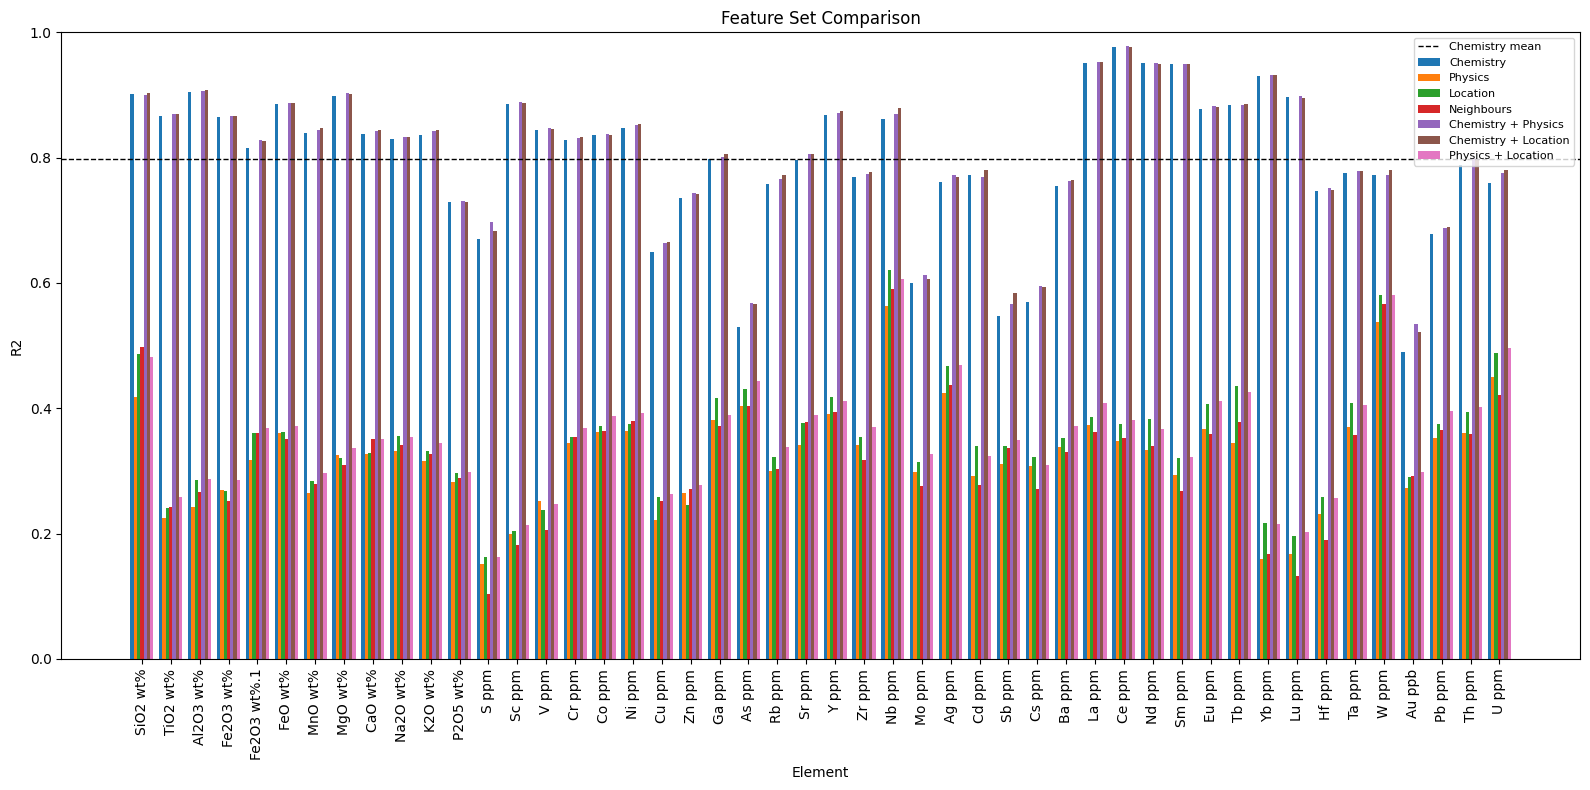

In [29]:
def DisplayFeatureSetGraph(allResults: dict[str, dict], elements: list[str], reference: str = "Chemistry", title: str = "Feature Set Comparison"):

    names = list(allResults)
    x = np.arange(len(elements))
    width = 0.8 / len(names)

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, name in enumerate(names):
        values = [allResults[name].get(element, {}).get("r2") or 0 for element in elements]
        offset = (i - (len(names) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=name)

    #The reference line makes it obvious which sets are worth anything at all
    referenceScore = np.mean([s["r2"] for s in allResults[reference].values() if s["r2"] is not None])
    ax.axhline(referenceScore, color="black", linestyle="--", linewidth=1, label=f"{reference} mean")

    ax.set_xlabel("Element")
    ax.set_ylabel("R2")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=90)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


DisplayFeatureSetGraph(results_feature_sets, elementsToTrain)

### Where the Gain Lands

The pooled mean hides the shape of the result. Binning targets by their **own baseline score** —
how much headroom own-chemistry left — separates the elements the model already predicts from the
ones it cannot, and scores every added feature source inside each bin.

Neighbours come from the KNN variant C results rather than the `Neighbours` feature set: that set
replaces own chemistry, where the question here is what each source adds *on top of* it.

============================ Gain over Chemistry, by Chemistry difficulty ============================
baseline R2:                n    mean   + Neighbours (KNN C)            + Physics           + Location
under 0.70:                 8  0.5920                +0.0517              +0.0238              +0.0219
0.70 - 0.85:               23  0.7927                +0.0102              +0.0058              +0.0070
0.85 - 0.95:               14  0.8909                +0.0044              +0.0026              +0.0034
over 0.95:                  3  0.9597                +0.0008              +0.0007              +0.0003


saturated targets (3):   La ppm, Ce ppm, Nd ppm


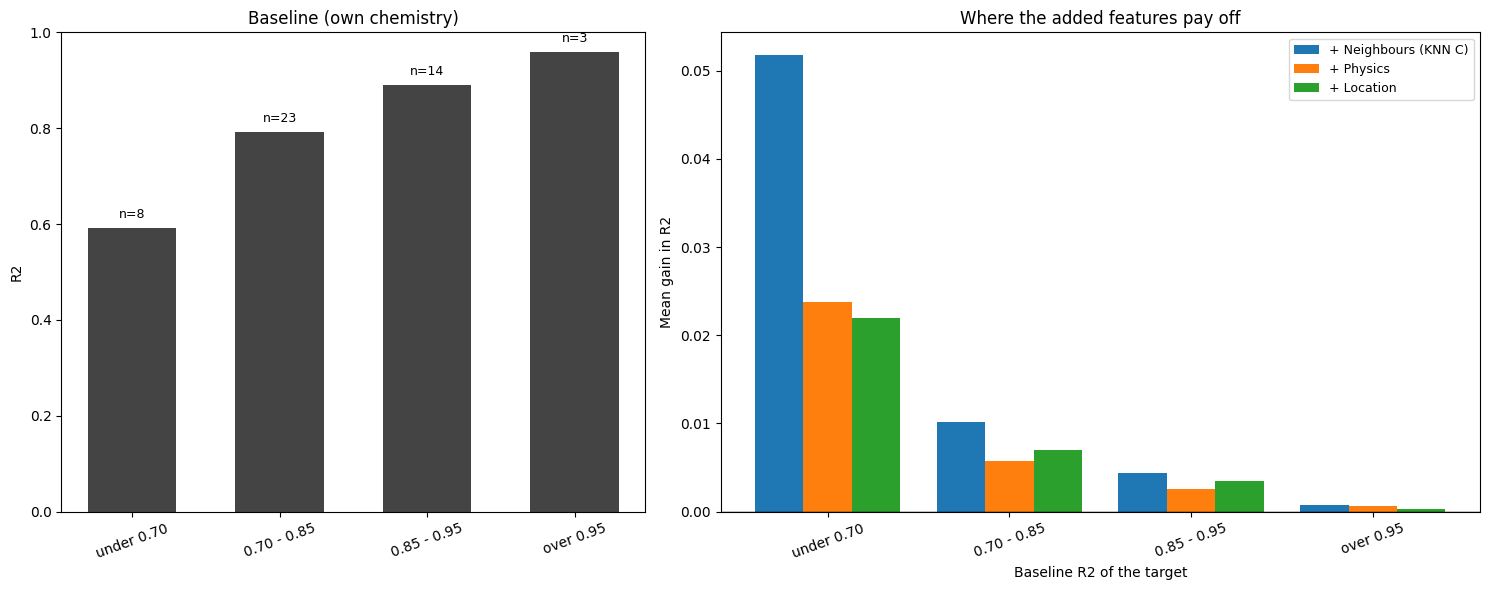

In [30]:
#Bins are on the baseline score itself, so each row groups targets by how much headroom
#own-chemistry left rather than by element type
DIFFICULTY_BINS = [(0.00, 0.70), (0.70, 0.85), (0.85, 0.95), (0.95, 1.01)]


def BinLabel(low: float, high: float, bins: list[tuple[float, float]]) -> str:
    if (low, high) == bins[0]:
        return f"under {high:.2f}"
    if (low, high) == bins[-1]:
        return f"over {low:.2f}"
    return f"{low:.2f} - {high:.2f}"


def GainByDifficulty(reference: dict, variants: dict[str, dict], bins: list[tuple[float, float]] = DIFFICULTY_BINS) -> list[dict]:
    """Mean gain over the reference, grouped by how well the reference already did."""

    rows = []
    for low, high in bins:
        elements = [element for element, score in reference.items()
                    if score["r2"] is not None and low <= score["r2"] < high]
        if not elements:
            continue

        row = {
            "label": BinLabel(low, high, bins),
            "elements": elements,
            "baseline": float(np.mean([reference[element]["r2"] for element in elements])),
        }

        for name, results in variants.items():
            #An element missing from a variant is skipped rather than counted as a zero gain
            gains = [results[element]["r2"] - reference[element]["r2"] for element in elements
                     if results.get(element, {}).get("r2") is not None]
            row[name] = float(np.mean(gains)) if gains else float("nan")

        rows.append(row)

    return rows


def ReportGainByDifficulty(rows: list[dict], variants: list[str], reference: str = "Chemistry"):

    printable = Printable()
    printable.title(f"Gain over {reference}, by {reference} difficulty")
    printable.add("baseline R2", f"{'n':>4} {'mean':>7}   " + " ".join(f"{name[:20]:>20}" for name in variants))

    for row in rows:
        cells = " ".join(f"{row[name]:>+20.4f}" for name in variants)
        printable.add(row["label"], f"{len(row['elements']):>4} {row['baseline']:>7.4f}   {cells}")

    printable.rest()
    #The last row is the point of the table, so its members are worth naming outright
    printable.add(f"saturated targets ({len(rows[-1]['elements'])})", ", ".join(rows[-1]["elements"]))

    printable.flush()


def DisplayGainByDifficulty(rows: list[dict], variants: list[str], title: str = "Where the added features pay off"):

    x = np.arange(len(rows))
    width = 0.8 / len(variants)

    fig, (axLeft, axRight) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.3]})

    axLeft.bar(x, [row["baseline"] for row in rows], 0.6, color="#444444")
    axLeft.set_xticks(x, [row["label"] for row in rows], rotation=20)
    axLeft.set_ylim(0, 1)
    axLeft.set_ylabel("R2")
    axLeft.set_title("Baseline (own chemistry)")
    for i, row in enumerate(rows):
        axLeft.text(i, row["baseline"] + 0.02, f"n={len(row['elements'])}", ha="center", fontsize=9)

    for i, name in enumerate(variants):
        offset = (i - (len(variants) - 1) / 2) * width
        axRight.bar(x + offset, [row[name] for row in rows], width, label=name)

    axRight.axhline(0, color="black", linewidth=1)
    axRight.set_xticks(x, [row["label"] for row in rows], rotation=20)
    axRight.set_xlabel("Baseline R2 of the target")
    axRight.set_ylabel("Mean gain in R2")
    axRight.set_title(title)
    axRight.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


#Variant C is the pooled neighbour encoding the k-sweep settled on; the feature-set
#"Neighbours" entry cannot be used here because it drops own chemistry instead of adding to it
gainVariants = {
    "+ Neighbours (KNN C)": results_kfold_knn["C"],
    "+ Physics":            results_feature_sets["Chemistry + Physics"],
    "+ Location":           results_feature_sets["Chemistry + Location"],
}

difficultyRows = GainByDifficulty(results_feature_sets["Chemistry"], gainVariants)

ReportGainByDifficulty(difficultyRows, list(gainVariants))
DisplayGainByDifficulty(difficultyRows, list(gainVariants))